# MATH Competition - Qwen3-8B

**Tinker RL Project — PES University MTech Capstone (Group 6)**

| Field | Value |
|-------|-------|
| **Model** | `Qwen/Qwen3-8B` |
| **Parameters** | 8.2B |
| **Benchmark** | MATH (Competition-Level Mathematics) |
| **Method** | GRPO (Group Relative Policy Optimization) + LoRA rank 32 |
| **Training API** | Tinker (Thinking Machines) — cloud GPU training |
| **Environment** | Atropos (NousResearch) — RL rollout framework |
| **Status** | In Progress |
| **Tinker URI** | `N/A (running)` |


## Experiment Description

This experiment trains Qwen3-8B on the MATH competition dataset (EleutherAI/hendrycks_math),
which includes problems from AMC, AIME, and other math competitions — significantly harder than GSM8K.

**Key observations so far:**
- Much harder than GSM8K — rewards are ~3-14% range after 25 steps
- The model struggles with competition-level problems requiring deeper reasoning
- Longer token lengths (1024 vs 512) needed for complex proofs and derivations
- This validates that GSM8K success doesn't automatically transfer to harder math



## Training Configuration

In [1]:
# Training configuration (math_qwen_8b.yaml)
config_yaml = """
# MATH Competition GRPO - Qwen3-8B
# Experiment: Competition math (harder than GSM8K)

env:
  group_size: 16
  batch_size: 128
  max_batches_offpolicy: 3
  tokenizer_name: "Qwen/Qwen3-8B"
  use_wandb: false
  rollout_server_url: "http://localhost:8012"
  wandb_name: "math-qwen3-8b-env"
  ensure_scores_are_not_same: false
  max_token_length: 1024
  max_num_workers: 24
  total_steps: 50
  steps_per_eval: 25

openai:
  - model_name: "Qwen/Qwen3-8B"
    base_url: "http://localhost:8013/v1"
    api_key: "x"
    weight: 1.0
    num_requests_for_eval: 256

tinker:
  lora_rank: 32
  learning_rate: 0.00004
  max_token_trainer_length: 2048
  checkpoint_dir: "./checkpoints/math_qwen8b/"
  save_checkpoint_interval: 10
  wandb_project: "tinker-rl-scaling"
  wandb_group: "math-scaling-ladder"
  wandb_run_name: "math-qwen3-8b"

slurm: false
testing: false"""
print(config_yaml)


# MATH Competition GRPO - Qwen3-8B
# Experiment: Competition math (harder than GSM8K)

env:
  group_size: 16
  batch_size: 128
  max_batches_offpolicy: 3
  tokenizer_name: "Qwen/Qwen3-8B"
  use_wandb: false
  rollout_server_url: "http://localhost:8012"
  wandb_name: "math-qwen3-8b-env"
  ensure_scores_are_not_same: false
  max_token_length: 1024
  max_num_workers: 24
  total_steps: 50
  steps_per_eval: 25

openai:
  - model_name: "Qwen/Qwen3-8B"
    base_url: "http://localhost:8013/v1"
    api_key: "x"
    weight: 1.0
    num_requests_for_eval: 256

tinker:
  lora_rank: 32
  learning_rate: 0.00004
  max_token_trainer_length: 2048
  checkpoint_dir: "./checkpoints/math_qwen8b/"
  save_checkpoint_interval: 10
  wandb_project: "tinker-rl-scaling"
  wandb_group: "math-scaling-ladder"
  wandb_run_name: "math-qwen3-8b"

slurm: false
testing: false


## Training Results

In [2]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (12, 5)

steps = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
rewards = [0.0312, 0.0312, 0.1016, 0.0469, 0.0234, 0.0, 0.0, 0.0938, 0.0391, 0.0156, 0.0547, 0.0234, 0.0938, 0.0469, 0.0156, 0.1406, 0.1016, 0.0547, 0.0312, 0.1328, 0.0859, 0.0391, 0.1406, 0.0938, 0.1406, 0.0547, 0.1875, 0.1094, 0.125]
losses = [190.78860473632812, 19.259552001953125, 680.705696105957, 27.9407958984375, 80.24624633789062, 0.0, 0.0, 1038.0061950683594, 0.45849609375, -1.015411376953125, 466.0011177062988, 623.31591796875, 514.8105163574219, 123.701416015625, 1.53851318359375, 984.7415771484375, 337.4224853515625, 145.036865234375, 85.07778930664062, 615.7445907592773, 610.6773071289062, -0.811553955078125, 202.3295669555664, 728.7622680664062, 884.3017272949219, 273.43915939331055, 615.7532306909561, 0.0, 160.1439971923828]

print(f"Total steps completed: {len(steps)}")
print(f"Initial reward: {rewards[0]:.4f}" if rewards else "No data")
print(f"Final reward: {rewards[-1]:.4f}" if rewards else "No data")
print(f"Peak reward: {max(rewards):.4f}" if rewards else "No data")
print(f"Mean reward (last 10): {sum(rewards[-10:])/len(rewards[-10:]):.4f}" if len(rewards) >= 10 else "")


Total steps completed: 29
Initial reward: 0.0312
Final reward: 0.1250
Peak reward: 0.1875
Mean reward (last 10): 0.1109


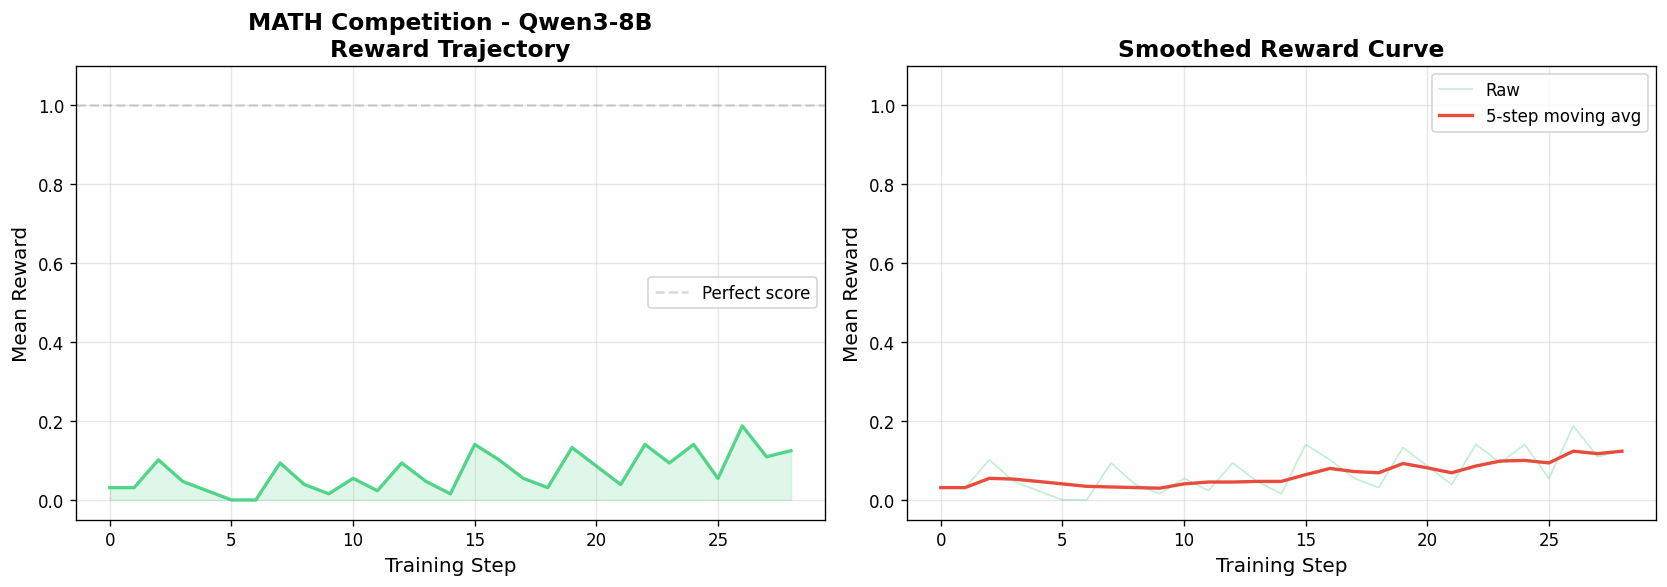

In [3]:
# Reward trajectory
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Reward curve
ax1.plot(steps, rewards, color='#2ecc71', linewidth=2, alpha=0.8)
ax1.fill_between(steps, rewards, alpha=0.15, color='#2ecc71')
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Mean Reward', fontsize=12)
ax1.set_title('MATH Competition - Qwen3-8B\nReward Trajectory', fontsize=14, fontweight='bold')
ax1.set_ylim(-0.05, 1.1)
ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, label='Perfect score')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Moving average
window = min(5, len(rewards))
if window > 1:
    moving_avg = [sum(rewards[max(0,i-window+1):i+1])/len(rewards[max(0,i-window+1):i+1]) for i in range(len(rewards))]
    ax2.plot(steps, rewards, color='#2ecc71', alpha=0.3, linewidth=1, label='Raw')
    ax2.plot(steps, moving_avg, color='#e74c3c', linewidth=2, label=f'{window}-step moving avg')
    ax2.set_xlabel('Training Step', fontsize=12)
    ax2.set_ylabel('Mean Reward', fontsize=12)
    ax2.set_title('Smoothed Reward Curve', fontsize=14, fontweight='bold')
    ax2.set_ylim(-0.05, 1.1)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

plt.tight_layout()
plt.show()


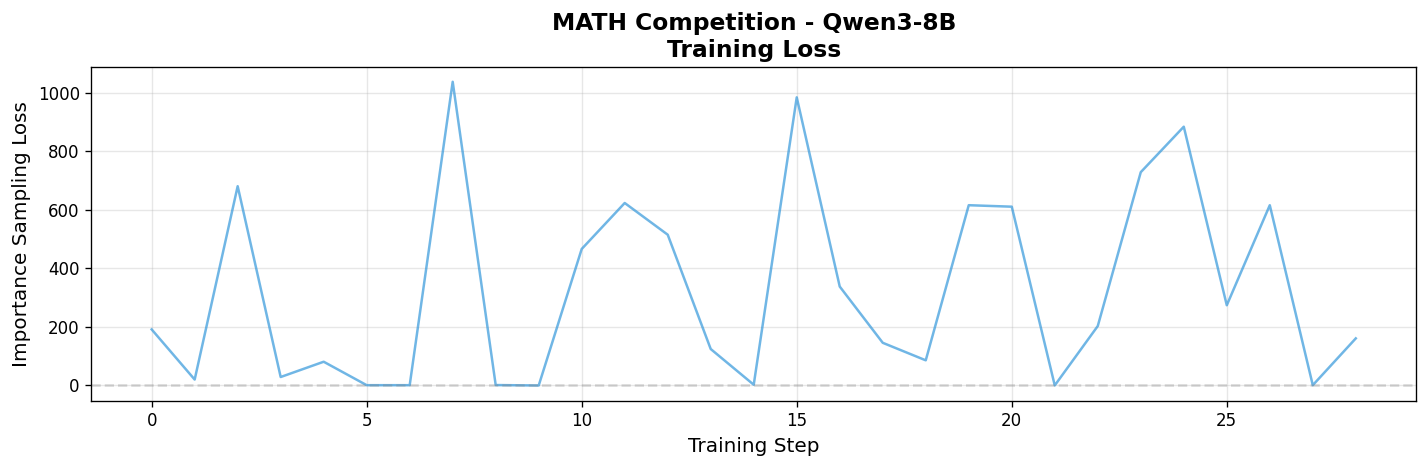

In [4]:
# Loss trajectory
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(steps, losses, color='#3498db', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Importance Sampling Loss', fontsize=12)
ax.set_title('MATH Competition - Qwen3-8B\nTraining Loss', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## Step-by-Step Data

In [5]:
import pandas as pd
df = pd.DataFrame({
    'Step': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28],
    'Reward': [0.0312, 0.0312, 0.1016, 0.0469, 0.0234, 0.0, 0.0, 0.0938, 0.0391, 0.0156, 0.0547, 0.0234, 0.0938, 0.0469, 0.0156, 0.1406, 0.1016, 0.0547, 0.0312, 0.1328, 0.0859, 0.0391, 0.1406, 0.0938, 0.1406, 0.0547, 0.1875, 0.1094, 0.125],
    'Loss': [190.78860473632812, 19.259552001953125, 680.705696105957, 27.9407958984375, 80.24624633789062, 0.0, 0.0, 1038.0061950683594, 0.45849609375, -1.015411376953125, 466.0011177062988, 623.31591796875, 514.8105163574219, 123.701416015625, 1.53851318359375, 984.7415771484375, 337.4224853515625, 145.036865234375, 85.07778930664062, 615.7445907592773, 610.6773071289062, -0.811553955078125, 202.3295669555664, 728.7622680664062, 884.3017272949219, 273.43915939331055, 615.7532306909561, 0.0, 160.1439971923828],
})
df['Reward_pct'] = (df['Reward'] * 100).round(2).astype(str) + '%'
print(df[['Step', 'Reward_pct', 'Loss']].to_string(index=False))


 Step Reward_pct        Loss
    0      3.12%  190.788605
    1      3.12%   19.259552
    2     10.16%  680.705696
    3      4.69%   27.940796
    4      2.34%   80.246246
    5       0.0%    0.000000
    6       0.0%    0.000000
    7      9.38% 1038.006195
    8      3.91%    0.458496
    9      1.56%   -1.015411
   10      5.47%  466.001118
   11      2.34%  623.315918
   12      9.38%  514.810516
   13      4.69%  123.701416
   14      1.56%    1.538513
   15     14.06%  984.741577
   16     10.16%  337.422485
   17      5.47%  145.036865
   18      3.12%   85.077789
   19     13.28%  615.744591
   20      8.59%  610.677307
   21      3.91%   -0.811554
   22     14.06%  202.329567
   23      9.38%  728.762268
   24     14.06%  884.301727
   25      5.47%  273.439159
   26     18.75%  615.753231
   27     10.94%    0.000000
   28      12.5%  160.143997


## Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│                    GRPO Training Pipeline                       │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  ┌─────────────┐    ┌──────────────┐    ┌───────────────────┐  │
│  │  Atropos     │───▶│  Environment │───▶│  Tinker Trainer   │  │
│  │  (run-api)   │    │  (GSM8K/MATH)│    │  (GRPO + LoRA)   │  │
│  │  Coordinator │◀───│  Scoring     │◀───│  Cloud GPUs      │  │
│  └─────────────┘    └──────────────┘    └───────────────────┘  │
│        │                    │                      │            │
│        │              Rollouts with           LoRA weights      │
│        │              binary rewards         updated via        │
│        │              (0 or 1)            importance sampling    │
│        │                    │                      │            │
│        └────────────────────┴──────────────────────┘            │
│                      Data flow loop                             │
└─────────────────────────────────────────────────────────────────┘
```
